# Análise de Dados – Programaria / State of Data 2022

Este notebook reúne o código produzido ao longo dos módulos do curso da Programaria,
utilizando como base a pesquisa **State of Data 2022** conduzida pelo Data Hackers.

**Aluna**: Sarah Mariana Guedes de Almeida

**Estrutura do notebook:**

| Seção | Conteúdo |
|---|---|
| 1. Exploração inicial | Leitura da planilha, inspeção de linhas, colunas e tipos de dados |
| 2. Filtragem e agrupamento | Filtros por gênero, idade, etnia; tabela dinâmica |
| 3. Estatística descritiva | Média, mediana, moda, desvio padrão, valores extremos |
| 4. Valores nulos | Identificação e preenchimento de nulos por estratégia |
| 5. Outliers | Detecção via desvio padrão e IQR; substituição por médias segmentadas |
| 6. Intervalo de confiança | Estimativa da média salarial com 95 % de confiança |
| 7. Feature engineering | Criação de novas colunas; codificação dummies; merge de tabelas |
| 8. Correlação | Pearson (variáveis contínuas) e Cramer (variáveis categóricas) |
| 9. SQL e índices socioeconômicos | Consultas a banco SQLite; correlação renda/educação x salário |
| 10. Visualização de dados | Matplotlib, Seaborn e Plotly |

**Bibliotecas utilizadas:** `pandas`, `numpy`, `scipy`, `matplotlib`, `seaborn`, `plotly`, `sqlite3`



---
## 1. Exploração inicial da base de dados
## Uso de biblioteca pandas
Nesta seção carregamos a planilha com `pd.read_excel()` e usamos as funções básicas
do pandas para entender o tamanho, os tipos de dados e o conteúdo da tabela antes
de qualquer transformação.

### 1.1 Importação de bibliotecas e carregamento dos dados

In [ ]:
import pandas as pd

In [ ]:
# Carrega a planilha do Google Drive e armazena no DataFrame 'dados' pelo caminho abaixo
dados = pd.read_excel('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/planilha_modulo3.xlsx')

### 1.2 Visualização rápida

As funções a seguir permitem inspecionar a tabela sem precisar exibi-la inteira:
- `head(n)` e `tail(n)`: primeiras/últimas *n* linhas.
- `shape`: retorna uma tupla `(linhas, colunas)` — é um **atributo**, não método, portanto não leva parênteses.
- `len()`: número de linhas (equivalente a `shape[0]`).
- `columns`: lista os nomes das colunas.
- `info()`: tipos de dados, contagem de não-nulos e uso de memória.
- `describe()`: estatísticas descritivas das colunas **numéricas** (contagem, média, desvio, quartis).


In [ ]:
# Ler a tabela
dados

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0


In [ ]:
# Funcao de ler as 10 primeiras linhas da tabela
dados.head(10)

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
8,8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,7112.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0


In [ ]:
# Funcao de ler as 10 ultimas linhas da tabela
dados.tail(10)
# os numeros que aparecem no canto esquerdo é o index

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0
4263,4263,02ido3x5siue5if02iz2taqjmcnh58xh,26.0,25-29,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,6641.0
4264,4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos,24543.0
4265,4265,01nmlhyw8w2b4stchg01nmlvlcqp0iis,28.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Marketing,de 1 a 5,0.0,NaN,Analista de Marketing,Pleno,de R$ 2.001/mês a R$ 3.000/mês,de 3 a 4 anos,de 1 a 2 anos,2348.0
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0
4270,4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,NaN,True,...,Agronegócios,de 501 a 1.000,0.0,NaN,Analista de Dados/Data Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3079.0


In [ ]:
# Ver o tamanho da planilha; não precisa de parenteses
# pois é um atributo da tabela, apenas retornando o tamanho
dados.shape

(4271, 28)

In [ ]:
# outra forma de ver as linhas
len(dados)

4271

In [ ]:
# vendo os nomes das colunas
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [ ]:
# Ver informacoes da tabela (range, colunas, tipos de dados, etc)
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

In [ ]:
# descrevendo os dados -> retorna as colunas
# que possuem valores NUMERICOS
dados.describe()

,Unnamed: 0,IDADE,MUDOU DE ESTADO?,GESTOR?,SALARIO
count,4271.000000,4197.000000,4171.000000,3694.000000,3694.000000
mean,2135.000000,31.169168,0.806281,0.193016,10969.266919
std,1233.075829,6.902803,0.395258,0.394719,19419.753189
min,0.000000,18.000000,0.000000,0.000000,35.000000
25%,1067.500000,26.000000,1.000000,0.000000,4269.500000
50%,2135.000000,30.000000,1.000000,0.000000,7625.500000
75%,3202.500000,35.000000,1.000000,0.000000,12778.500000
max,4270.000000,54.000000,1.000000,1.000000,485191.000000


---
## 2. Filtragem e agrupamento

O pandas permite filtrar linhas com expressões booleanas aplicadas diretamente
no DataFrame. Nesta seção reproduzimos análises equivalentes às feitas em Excel,
mas com código Python.


### 2.1 Filtragem por igualdade e desigualdade

A sintaxe geral é `dados[dados['COLUNA'] operador valor]`.



In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [ ]:
dados['GENERO']

,GENERO
0,Masculino
1,Masculino
2,Masculino
3,Masculino
4,Feminino
...,...
4266,Masculino
4267,Feminino
4268,Masculino
4269,Masculino


In [ ]:
# Filtro de genero -> colocar igualzinho o que ta na tabela
dados[dados['GENERO'] == 'Feminino']

# Filtramos tudo que esta na coluna de genero que é igual a feminino

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [ ]:
# Outra forma -> vamos filtrar tudo que nao é do genero masculino
dados[dados['GENERO'] != 'Masculino']
# aqui junta feminino + qualquer outra resposta

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


### 2.2 Filtragem por conteúdo textual parcial (`str.contains`)

`str.contains(texto, na=False)` verifica se a célula **contém** o trecho indicado.
O parâmetro `na=False` faz com que células nulas sejam tratadas como `False` em vez de
propagar o nulo. Sem ele, linhas nulas retornariam `NaN` e gerariam erros em operações subsequentes.


In [ ]:
# Funcao CONTAINS -> filtrar tudo que contem algo que vamos definir str.contains(palavra que buscamos)
dados[dados['GENERO'].str.contains('não', na=False)] # na preenche os valores nulos pelo que definimos

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
562,562,vhuw8xnpbmj6oh20xovhuwcbdl4a12ni,29.0,25-29,Prefiro não informar,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,1528,n2ktdn33istvlu1ha4v3kn2ktdn1rsp1,NaN,55+,Prefiro não informar,Indígena,Prefiro não informar,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 51 a 100,0.0,NaN,Analista de Suporte/Analista Técnico,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,826.0
1913,1913,k3as6jdh3w4jf4ztsw4kpkk3as6jdy19,30.0,30-34,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 101 a 500,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,de 3 a 4 anos,11476.0
1925,1925,jzppdwep2kpisqjjzppdh304v83cj7eu,NaN,17-21,Prefiro não informar,Prefiro não informar,Prefiro não informar,"Sim, acredito que minha experiência profission...",Quantidade de oportunidades de emprego/vagas r...,False,...,Setor Farmaceutico,de 1 a 5,0.0,NaN,Outra Opção,Júnior,de R$ 2.001/mês a R$ 3.000/mês,de 1 a 2 anos,Menos de 1 ano,2294.0
2554,2554,f5l206z0hr9uh3nz2iiff5l206c0g10o,20.0,17-21,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,1339.0
3090,3090,a6ugmsw7s8hu5aa6uglio5apj74fam9o,26.0,25-29,Prefiro não informar,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,de 101 a 500,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,11545.0
3357,3357,7q0icczxn0l3a894cbx7q0icczjyud0n,29.0,25-29,Prefiro não informar,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,6345.0
3493,3493,6m8haop6lxnaizpwij6m8haopiax98jg,25.0,25-29,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 3 a 4 anos,Menos de 1 ano,3900.0
3610,3610,5mloglozmr0r715mntaxbt6xy8b5olmb,30.0,30-34,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Velocidade de progressão de carreira,True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,10174.0
4171,4171,0rksyxnqhn13nwytwi6y0rkssx6jmodf,26.0,25-29,Prefiro não informar,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 1.001 a 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Menos de 1 ano,10517.0


In [ ]:
# nesse caso, todos os na sao false, mas poderia colocar outros valores
# vimos que apareceu tudo de Prefiro nao informar!

### 2.3 Filtragem numérica e filtros combinados

In [ ]:
dados[dados['IDADE']>=30]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0
4264,4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos,24543.0


In [ ]:
dados[(dados['IDADE']>30) & (dados['GENERO'] == 'Feminino')] # para colocar algo em parenteses selecione e aperte shift (

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
14,14,zwez49k0jhdvfkfst4zwef137uuf4ivy,35.0,35-39,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Pleno,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,7416.0
23,23,zuqfcwtl9unfc5ezuqfcwm8coytsp5ap,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,de 5 a 6 anos,13418.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,4214,0gprow0ownrbfneftxf0gprow4kyrqdy,41.0,40-44,Feminino,Branca,Prefiro não informar,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Seguros ou Previdência,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,11452.0
4221,4221,0fgi5bnb0u9b0fgc0jmqlbnvtu12b76d,34.0,30-34,Feminino,Outra,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Outra Opção,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5687.0
4240,4240,0a5xgxb1ljmuqn0un8a10a5xg4eufs2l,37.0,35-39,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,de 51 a 100,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,Menos de 1 ano,1182.0
4247,4247,07qzabp4ujpe4oz81udmb07qzabp4h0t,34.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor de Energia,de 11 a 50,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,5925.0


Desafio: Filtre as pessoas que responderam cor Amarela e Quantas pessoas existem abaixo de 40 anos

### 2.4 Explorando a coluna COR/RAÇA/ETNIA

`unique()` retorna os valores distintos de uma coluna. Útil para verificar
como as categorias estão escritas antes de fazer filtros por igualdade.


In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [ ]:
dados['COR/RACA/ETNIA']

,COR/RACA/ETNIA
0,Parda
1,Parda
2,Branca
3,Branca
4,Branca
...,...
4266,Branca
4267,Branca
4268,Branca
4269,Branca


In [ ]:
dados['COR/RACA/ETNIA'].unique() #mostra as respostas unicas


array(['Parda', 'Branca', 'Amarela', 'Preta', 'Prefiro não informar',
       'Indígena', 'Outra'], dtype=object)

In [ ]:
dados[(dados['IDADE']<40)& (dados['COR/RACA/ETNIA'] == 'Amarela')]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
170,170,yri3z491ejizlpj9ylu2k3jyri3z4915,34.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,16650.0
195,195,yjbpxmkqz5yidh5oszyjbpxmkgcb1zd9,32.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3947,3947,2tnsh0gxdu3aq4z2d2tnsh0hk15brx7q,31.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,False,...,Tecnologia/Fábrica de Software,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 25.001/mês a R$ 30.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,29408.0
4058,4058,1t3ndwx8j50k0bz1t3ndwxdpwyg17c2k,27.0,25-29,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Nível de cobrança no trabalho / Stress no trab...,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,14175.0
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0


In [ ]:
dados[dados['COR/RACA/ETNIA'] == 'Amarela']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,zbukfwxvpwlk6loglm0zbukfwx6bvyb6,40.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Mais de 10 anos,11388.0
107,107,z9toybzbja7n6xjjbz9f8hmofrry69tg,44.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Indústria,Acima de 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,Mais de 10 anos,14500.0
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0
4210,4210,0hbwm1d1wz739r40hbwm1df6ky5kn4ap,43.0,40-44,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Sênior,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Mais de 10 anos,7131.0
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0


In [ ]:
dados[dados['IDADE']>40]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
23,23,zuqfcwtl9unfc5ezuqfcwm8coytsp5ap,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,de 5 a 6 anos,13418.0
48,48,zpmshqhzkm5y6ay6izdzpmshqzpxnzrs,46.0,45-49,Masculino,Branca,Não,NaN,NaN,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14796.0
68,68,zjmg0dwnz7foz9zjdeqaxusoa6lb7mbe,48.0,45-49,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Internet/Ecommerce,Acima de 3.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 25.001/mês a R$ 30.000/mês,de 4 a 6 anos,Mais de 10 anos,29734.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4223,4223,0fba51yz2clzkxu90fba51ybxel3l2s0,47.0,45-49,Masculino,Branca,Não,NaN,NaN,True,...,Entretenimento ou Esportes,Acima de 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 20.001/mês a R$ 25.000/mês,Mais de 10 anos,Mais de 10 anos,24337.0
4226,4226,0eruf0rg61qfsph69m60eruh2xtza4pd,45.0,45-49,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4230,4230,0dwvv25uon62gh6p0dwvv2are22wnwr9,49.0,45-49,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Professor,Sênior,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10128.0
4243,4243,09263ihto6jiqwrkpv3bzo09263ihxqk,41.0,40-44,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Mais de 10 anos,10801.0


### 2.5 Agrupamento com `groupby` e contagem de valores

- `groupby('COLUNA')['OUTRA'].nunique()`: agrupa pela primeira coluna e conta
  quantos valores únicos existem na segunda: responder 'quantas pessoas
  distintas existem por categoria?'.
- O parâmetro `dropna=False` faz o `groupby` incluir registros em que a coluna de
  agrupamento é nula; sem ele, esses registros seriam silenciosamente descartados.
- `value_counts(dropna=False)` conta quantas vezes cada valor aparece na coluna,
  incluindo nulos.


In [ ]:
dados.groupby('GENERO')['ID'].nunique() # aqui estamos agrupando dados e somando os valores unicos com nunique

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12


In [ ]:
dados.groupby('GENERO', dropna = False )['ID'].nunique() # agora mostra os valores nulos com o DROPNA

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12
NaN,9


In [ ]:
dados['GENERO'].value_counts(dropna = False) # por padrao a value counts nao mostra nulos, ai tem que colocar os valores nulos

,count
GENERO,
Masculino,3194
Feminino,1056
Prefiro não informar,12
NaN,9


### 2.6 Agrupamento encadeado com filtro

Filtros e agrupamentos podem ser encadeados em uma única expressão:
`dados[filtro]['COLUNA'].value_counts()` primeiro filtra as linhas e depois
conta os valores da coluna resultante.

In [ ]:
dados[dados['IDADE']>30]['NIVEL'].value_counts() #acima dos 30 anos, temos essa quantidade de pessoas por NIVEL

,count
NIVEL,
Sênior,525
Pleno,408
Júnior,274


In [ ]:
dados[(dados['IDADE']>30) & (dados['GENERO']== 'Feminino')]['NIVEL'].value_counts() # estamos vendo todo mundo maior que 30 anos, que marcou que é feminino, vendo por nivel.

,count
NIVEL,
Pleno,117
Sênior,114
Júnior,96


### 2.7 Tabela dinâmica com `pd.pivot_table`

`pd.pivot_table` organiza os dados em formato cruzado, similar a uma tabela dinâmica
do Excel. Os parâmetros principais são:
- `values`: coluna que será agregada.
- `index`: coluna que formará as linhas.
- `columns`: coluna que formará as colunas.
- `aggfunc`: função de agregação (`'count'`, `'sum'`, `'mean'` etc.).


In [ ]:
pd.pivot_table(dados, values = ['ID'], index = ['GENERO'], columns = ['GESTOR?'], aggfunc= 'count')

ID     
GESTOR?                0.0  1.0
GENERO                         
Feminino               754  132
Masculino             2212  578
Prefiro não informar     9    2

In [ ]:
# sempre voltar no cookbook!

---
## 3. Estatística descritiva - Módulo 4

Estatística descritiva resume as características principais de um conjunto de dados
por meio de medidas de tendência central (média, mediana, moda) e de dispersão
(desvio padrão, mínimo, máximo).

### 3.1 Importação do NumPy

In [ ]:
# importando a biblioteca Numpy

import numpy as np # np é o apelido de numpy, para facilitar escrita.

In [ ]:
lista_idades = [26,30,32,22,26,35,40,20,43,31,23] # temos uma lista de idades que é definida por meio dos valores dentro dos colchetes

### 3.2 Média (`mean`)

A média aritmética é a soma de todos os valores dividida pela quantidade de valores.
Ela é sensível a valores extremos (outliers): um único valor muito alto ou muito baixo
pode distorcer o resultado.

`np.sum(), len(), np.mean(), np.average()`

In [ ]:
# a média é calculada pela soma de todos os valores, dividida pelo número de valores existentes.

np.sum(lista_idades) # np.sum() soma os valores da lista

np.int64(328)

In [ ]:
# para saber a quantidade de valores, usamos a funçao len()

len(lista_idades)

11

In [ ]:
# fazendo a média
(np.sum(lista_idades)) / (len(lista_idades)) # / significa dividir

np.float64(29.818181818181817)

In [ ]:
# mas temos a funçao mean do numpy, que serve para fazer média!

media = np.mean(lista_idades)
media

print('Media aritmetica:', media)

Media aritmetica: 29.818181818181817


In [ ]:
# média ponderada -> os valores possuem pesos
# para isso, utilizamos np.average(dados, weights = pesos)

### 3.3 Mediana (`median`)

A mediana é o valor do meio quando os dados estão ordenados.
Quando a quantidade de valores é par, a mediana é a média dos dois valores centrais.
Ao contrário da média, a mediana é **resistente a outliers**.
`sort(), np.median()`


In [ ]:
# mediana -> procuramos o valor que está no meio
# Podemos usar sort para ordenar e ver o valor do meio

# ordenando a lista em ordem crescente:

lista_idades.sort()
lista_idades

[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43]

In [ ]:
lista_idades = [26,30,32,22,26,35,40,20,43,31,23,100]

In [ ]:
lista_idades.sort()
lista_idades

# se a mediana estiver num numero de valores pares, pegamos os dois valores do meio e fazemos a média

[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43, 100]

In [ ]:
# a funçao de mediana

mediana = np.median(lista_idades)
mediana

np.float64(30.5)

### 3.4 Aplicando média e mediana na tabela do Data Hackers

In [ ]:
dados['IDADE'].mean() # também tem como fazer a média usando o pandas com o .mean()

np.float64(31.169168453657374)

In [ ]:
dados['IDADE'].median()

30.0

### 3.5 Moda

A moda é o valor que aparece com maior frequência. Diferente da média e da mediana,
pode existir mais de uma moda (distribuição bimodal ou multimodal).
No pandas, `.mode()` retorna uma Series com a(s) moda(s).


In [ ]:
dados['IDADE'].mode() # vamos saber a idade que mais aparece

,IDADE
0,27.0


### 3.6 Desvio padrão

O desvio padrão mede a dispersão dos dados em relação à média:
quanto mais próximo de zero, mais homogêneos são os dados;
quanto maior, mais espalhados.
No pandas, `.std()` usa a correção de Bessel (divide por *n-1*, não *n*),
adequada para amostras.

In [ ]:
dados['IDADE'].std()

6.902802832143141

In [ ]:
# tendo em vista o tamanho da tabela de 4000 e poucos, o DP de 7 é um valor alto.

### Valor mínimo
> Utilizamos .min() no pandas

In [ ]:
dados['IDADE'].min()

18.0

### Valor máximo
> Utilizamos .max() no pandas

In [ ]:
dados['IDADE'].max()

54.0

### 3.8 Comparando médias por grupo

Calcular a mesma métrica para subgrupos permite identificar diferenças entre categorias.
Abaixo comparamos médias de idade e salário entre os gêneros.

> Vamos calcular a média de idade das pessoas que responderam a coluna GENERO como Feminino e depois Masculino


In [ ]:
dados[dados['GENERO'] == 'Feminino']['IDADE'].mean()

np.float64(31.318051575931232)

In [ ]:
dados[dados['GENERO'] == 'Masculino']['IDADE'].mean()

np.float64(31.147876077930373)

In [ ]:
# Notamos que a média geral é bem parecida.

### Fazendo cálculos com a Coluna salário

> a coluna não existe na base original, foi adicionada pelo curso para treinarmos.

> Qual o valor min e max de salário? Qual a média? Qual o DP?

> Com essas análises, responda: A Média de salário das mulheres e dos homens tem diferença significativa?

In [ ]:
dados[dados['GENERO'] == 'Masculino']['SALARIO'].mean()


np.float64(11724.552688172043)

In [ ]:
dados[dados['GENERO'] == 'Feminino']['SALARIO'].mean()

np.float64(8673.22460496614)

In [ ]:
# Com isso, percebe-se que a diferença é aprox 3000, significativa.

---
## 4. Tratamento de valores nulos - Aula 4.2

Valores nulos (`NaN`) ocorrem quando respondentes deixaram campos em branco.
Existem três estratégias principais:

1. **Remover** as linhas com nulos — simples, mas pode reduzir muito a amostra, podendo atrapalhar os dados e deixando pouca informação.

2. **Substituir pela média/mediana** — preserva a amostra; indicado para colunas numéricas, tabelas pequenas ou mais homogêneas.

Uma limitação dessa substituição é ignorar a **covariância** entre variáveis
(por exemplo, idade e faixa etária estão relacionadas — podemos usar uma para
estimar a outra, como feito abaixo).

3. **Substituir pela moda** — indicado para colunas categóricas.

4. Criar um modelo de **Machine Learning**


### 4.1 Panorama geral dos nulos

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

In [ ]:
# As que não são o número 4271 possuem valores nulos!

### 4.2 Tratando a coluna GENERO

In [ ]:
dados.groupby('GENERO', dropna = False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12
NaN,9


In [ ]:
# Observando esse contexto, podemos colocar esses 9 nulos em Prefiro Nao informar

#### Preenchendo valores
> função fillna() preenche os valores nulos com o que tiver dentro do parametro.

In [ ]:
dados['GENERO'] = dados['GENERO'].fillna('Prefiro não informar') # atribuimos o valor do fillna a coluna de Genero, tratando ela.

In [ ]:
dados.groupby('GENERO', dropna = False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,21


In [ ]:
# No caso de colunas numéricas, existe o padrão de preencher por -1, desde que isso não atrapalhe as análises.

### 4.3 Tratando a coluna IDADE

A estratégia aqui é mais sofisticada: como todos os respondentes que deixaram
IDADE em branco preencheram a FAIXA IDADE, podemos usar a média de cada faixa
como estimativa — em vez de usar a média geral, que seria menos precisa.

In [ ]:
dados['IDADE'].isnull() # False = tá preenchida e True = não tem valor

,IDADE
0,False
1,False
2,False
3,False
4,False
...,...
4266,False
4267,False
4268,False
4269,True


In [ ]:
dados['IDADE'].isnull().value_counts() # vamos contar os nulos dessa coluna

,count
IDADE,
False,4197
True,74


In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [ ]:
# vamos fazer um filtro para analisar se essas pessoas colocaram algo na Faixa de idade

dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

,count
FAIXA IDADE,
55+,68
17-21,6


In [ ]:
# vimos que dos 74 nulos, todos preencheram a faixa idade!
# vamos, então, substituir os 68 valores pela média das idades 55+, e os 6 valores pela média das idades 17-21

In [ ]:
media_17_21 = dados[dados['FAIXA IDADE'] == '17-21']['IDADE'].mean()

In [ ]:
# vamos localizar as células nulas

dados.loc[(dados['FAIXA IDADE'] == '17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21

In [ ]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

,count
FAIXA IDADE,
55+,68


In [ ]:
# Nao tivemos nenhum valor preenchido em faixa idade, por isso vamos usar a média geral para preencher esses valores.

In [ ]:
dados[dados['FAIXA IDADE'] == '55+']['IDADE']

,IDADE
9,NaN
66,NaN
96,NaN
121,NaN
156,NaN
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [ ]:
dados[dados['FAIXA IDADE'] == '55+']['NIVEL']

,NIVEL
9,Pleno
66,Júnior
96,Pleno
121,Pleno
156,Júnior
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [ ]:
media_geral = dados['IDADE'].mean()
media_geral

np.float64(31.153517220250375)

In [ ]:
dados.loc[(dados['FAIXA IDADE'] == '55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_geral

In [ ]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

,count
FAIXA IDADE,


### 4.4 Tratando a coluna SALARIO

Para salário, optamos pela **mediana** em vez da média, porque a distribuição
salarial tende a ter assimetria positiva (valores altos puxam a média para cima).
A mediana é menos afetada por esses extremos.

In [ ]:
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
12,12,zwr9hqcpg513kaopenzwr9hibaqmldto,31.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,ztgepgj82o9oix0nztgepq2trcay6gpv,24.0,22-24,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,zsa9i6njd3e594mw0tvlk4zsa9iw86i9,24.0,22-24,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,zr4b2vm7dapp3linwqwn7zr4b2vmagqx,32.0,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,zm7o5yquakof0j6zm7vh3o0letznhdvh,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4242,4242,09oxwp6lsdwhw09ox1uobuxa8cq2pzma,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4252,4252,064pe9b1htw7mflhif064pe95dotv6yf,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


In [ ]:
# Vamos usar a mediana, pois ela é menos afetada por valores discrepantes para substituir valores nulos

In [ ]:
mediana_salario = dados['SALARIO'].median()

In [ ]:
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario

In [ ]:
dados[dados['SALARIO'].isnull()].value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,UF ONDE MORA,REGIAO ONDE MORA,MUDOU DE ESTADO?,REGIAO DE ORIGEM,NIVEL DE ENSINO,ÁREA DE FORMAÇÃO,QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO,


---
## 5. Detecção e tratamento de outliers

Outliers são valores muito distantes dos demais — podem ser erros de entrada
ou casos legítimos mas raros. Existem dois métodos principais de detecção:

1. **Desvio padrão**: considera outlier o que está além de ±3 desvios da média.
2. **IQR (Intervalo Interquartil)**: considera outlier o que está abaixo de
   Q1 − 1,5×IQR ou acima de Q3 + 1,5×IQR. Mais robusto a distribuições assimétricas.

### 5.1 Demonstração

In [ ]:
lista_idades = [26,30,32,22,26,35,400,20,43,31,23]

In [ ]:
media = np.mean(lista_idades)
media

np.float64(62.54545454545455)

In [ ]:
# O valor 400 é um exemplo de um valor OUTLIER. Tratar esses valores é importante para deixar a análise mais robusta e correta.
# precisamos identificá-los, principalmente, com o DP

In [ ]:
desvio = np.std(lista_idades)
desvio

np.float64(106.89532997398872)

> 106 é um valor enorme. Isso mostra uma alta probabilidade de outliers.

In [ ]:
# Confirmando a existencia de Outliers
media + 3*desvio


np.float64(383.2314444674207)

In [ ]:
# Acima de 383 é tudo outlier (limite superior)

In [ ]:
media - 3*desvio

np.float64(-258.1405353765116)

In [ ]:
# Tudo abaixo de -258 é outlier (limite inferior)

#### Quartis
> Dividimos os dados em 4 partes utilizando 3 valores

> O quartil do meio é a mediana

> O primeiro quartil é a metade debaixo da mediana e o terceiro quartil é a parte de cima

> Visualizamos isso com BOX PLOT


## A bilioteca matplotlib

> possui diversos recursos para visualizar dados e plotagem de gráficos 2d e 3d

In [ ]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x7e2dfac43650>,
 'caps': [<matplotlib.lines.Line2D at 0x7e2dfabe3110>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e2dfab93110>],
 'medians': [<matplotlib.lines.Line2D at 0x7e2dfabe37a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e2dfabe3a70>],
 'means': []}

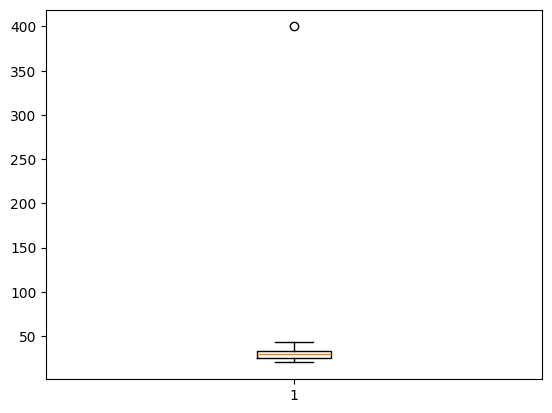

In [ ]:
# Vamos plotar nosso boxplot

plt.boxplot(lista_idades)

In [ ]:
# A linha laranja é a nossa mediana. As bordas da caixinha sao os quartis Q1 e Q3 e as linhas abaixos e acima sao os limites!
# Tudo além dessas linhas sao os outliers (a bolinha, que é o 400)

## Aplicando o boxplot na tabela do Data Hackers

{'whiskers': [<matplotlib.lines.Line2D at 0x7e2dfa8231d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7e2dfa87ccb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e2dfa87c440>],
 'medians': [<matplotlib.lines.Line2D at 0x7e2dfa87d280>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e2dfa87d5e0>],
 'means': []}

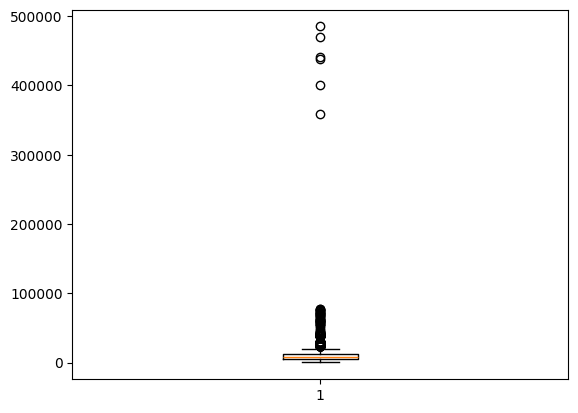

In [ ]:
plt.boxplot(dados['SALARIO'])

> Podemos ver que a caixa está mais ou menos abaixo do 50 mil, mas temos alguns valores lá em cima, que sao os Outliers

> Vamos calcular os limites certinhos utilizando a funçao Quantile()
> O primeiro quartil pega o valor que separa 1/4 dos dados. Chamamos ele e passamos o parametro 0.25

> O terceiro quartil separa 3/4 dos dados. Passamos o parametro 0.75

In [ ]:
Q1 = dados['SALARIO'].quantile(0.25)
Q1

np.float64(4751.5)

In [ ]:
Q3 = dados['SALARIO'].quantile(0.75)
Q3

np.float64(11794.5)

Interquartil
> Define o valor entre o 1 e o 3 quartil


In [ ]:
IQR = Q3 - Q1
IQR

np.float64(7043.0)

Pegando os limites
> Vamos definir que o limite superior é o Q3 + 1.5 * interquartil

> O inferior é Q1 - 1.5 * interquartil

In [ ]:
lim_superior = Q3 + (1.5 * IQR)
lim_superior

np.float64(22359.0)

In [ ]:
lim_inferior = Q1 - (1.5 * IQR)
lim_inferior

np.float64(-5813.0)

In [ ]:
dados['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
de R$ 8.001/mês a R$ 12.000/mês,752
de R$ 4.001/mês a R$ 6.000/mês,584
de R$ 6.001/mês a R$ 8.000/mês,527
de R$ 12.001/mês a R$ 16.000/mês,437
de R$ 3.001/mês a R$ 4.000/mês,303
de R$ 2.001/mês a R$ 3.000/mês,285
de R$ 16.001/mês a R$ 20.000/mês,229
de R$ 1.001/mês a R$ 2.000/mês,216
de R$ 20.001/mês a R$ 25.000/mês,134


Existe outro método de cálculo do limite superior que considera que todo valor que está a uma certa distancia da média é outlier

> Essa distancia é calculada considerando o Desvio padrão, já que ele ve a dispersão dos dados.

In [ ]:
media_salario = np.mean(dados['SALARIO'])
media_salario

np.float64(10517.53348162023)

In [ ]:
desvio_salario = dados['SALARIO'].std()
desvio_salario

18096.210989118474

In [ ]:
# Limite superior
# Média + n desvios padroes
# n varia de acordo com a sensibilidade da análise e da distribuiçao dos dados
# determinamos isso pelo contexto: por exemplo se os outliers de salario estiverem BEM acima, poderiamos usar n = 3

In [ ]:
limite_superior = media_salario + (3*desvio_salario)
limite_superior

np.float64(64806.16644897565)

In [ ]:
# Entao tudo acima de 64mil seria outlier. Faz sentido as pessoas terem esse salário?

### O que fazemos com os outliers?

> Podemos remover eles do banco de dados, mas devemos tomar cuidado, pois isso pode distorcer a conclusão!

> Uma abordagem é substituí-los por valores mais adequados, como a mediana(já que a média é sensível a valores discrepantes) ou substituir pelo valor max.

>** Importante demais estudar o contexto dos dados!** Apesar de serem eventos raros, podem ser importantes para a análise

In [ ]:
# Vamos ver se esses outliers marcaram uma faixa salarial correspondente
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19
de R$ 30.001/mês a R$ 40.000/mês,3


In [ ]:
# Podemos fazer a média dos salarios acima de 40.000 SEM os outliers e substituir, e depois fazer a média dos valores 30 a 40 mil também

In [ ]:
media_30_40 = dados[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()

In [ ]:
dados.loc[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_30_40

In [ ]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19


Fazendo agora com o filtro Acima de 40 mil

In [ ]:
media_acima_40 = dados[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()

In [ ]:
dados.loc[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_acima_40

In [ ]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


### Refazendo o BOX PLOT

{'whiskers': [<matplotlib.lines.Line2D at 0x7e2dfaa8c6e0>,
 'caps': [<matplotlib.lines.Line2D at 0x7e2dfa8c2d80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e2dfaa8c410>],
 'medians': [<matplotlib.lines.Line2D at 0x7e2dfaa8d190>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e2dfaa8d4c0>],
 'means': []}

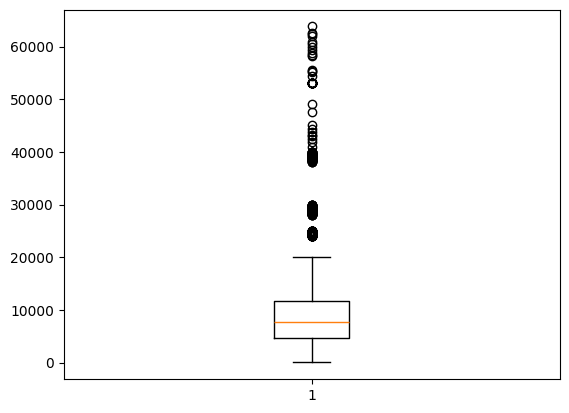

In [ ]:
plt.boxplot(dados["SALARIO"])

A abordagem escolhida para lidar com os Outliers deve sempre ser levada em conta com base a natureza dos dados, nos objetivos da análise e no contexto do problema.

Não possui uma soluçao unica, devemos avaliar com cuidado!


---
## 6. Intervalo de confiança e distribuição amostral
> Vamos supor que queremos saber a altura média de alunos de uma escola, mas não conseguimos medir todos. Assim, pegamos uma amostra de alunos e medimos a alturas. Como sabemos se essa amostra representa bem o conjunto da escola? Aqui entra o intervalo de confiança.

>O intervalo de confiança te dá uma faixa de valores onde a média da população provavelmente está. É como um palpite bem certo

>Exemplo: Encontramos a média de 1.67cm. O intervalo de confiança é 95% que é 1.65 a 1.75. Isso significa que com 95% de certeza a média de altura dos alunos está nessa faixa. É como uma margem de erro para a estimativa baseada na amostra.

> Quanto maior o intervalo de confiança, mais confiavel será a estimativa, mas tb mais amplo é o intervalo.

> A distribuição amostral é como ter uma espécie de repetição dos experimentos imaginários feitos com as amostras. EX:

> Ao invés de medir todos os alunos, decidimos pegar amostras diferentes, cada uma com alguns alunos e calcula a média de altura de cada amostra. Juntando essas médias, temos uma distribuição amostral das médias de altura, util para mostrar como as médias das amostras variam.

Cálculo usando `scipy.stats`:
- `stats.sem(dados)`: erro padrão da média (desvio padrão dividido por √n).
- `stats.t.interval(confiança, df, loc, scale)`: intervalo baseado na distribuição t de Student.


### Na tabela do DATA HACKERS, vamos ver se a média de salarios é representativa para o salário brasileiro?

In [ ]:
# Primeiro, o tamanho da amostra é suficiente para fazer isso? É proporcional?

In [ ]:
salarios = dados["SALARIO"]

In [ ]:
media_amostral = np.mean(salarios)
media_amostral

np.float64(9904.390109813306)

In [ ]:
desvio_amostral = np.std(salarios)
desvio_amostral

8306.104872579343

In [ ]:
nivel_confianca = 0.95

In [ ]:
tamanho_amostra = len(salarios)
tamanho_amostra

4271

In [ ]:
# Calculando o erro padrão - dividir em grupinhos e fazer as médias
# a diferença das médias é o erro padrão

### Temos uma função pronta para dividir em vários grupinhos, da biblioteca SCIPY
> stats.sem()

> stats.t.interval() -> recebe parametros como o nível de confiança, o número de graus de liberade da distribuição(tamanho amostra - 1), o loc(média amostral) e o scale

In [ ]:
from scipy import stats # importamos o módulo stats da bib scipy

In [ ]:
# calculamos o erro médio padrão

erro_padrao = stats.sem(salarios)
erro_padrao

np.float64(127.11109872023638)

In [ ]:
# Vamos calcular o intervalo de confiança
intervalo_confianca = stats.t.interval(nivel_confianca, (tamanho_amostra - 1), loc = media_amostral, scale = erro_padrao )
intervalo_confianca

(np.float64(9655.186295869078), np.float64(10153.593923757535))

> Ou seja, de acordo com os dados, temos 95% de confiança que a média de salários de cientistas do brasil está entre 9655 a 10153!

**Desafio:** altere o nível de confiança e veja como será alterado o intervalo de confiança

> Faça isso com as idades também e descubra com 90% de confiança qual o intervalo que a média de idades vai estar

> Calcule com 90% de confiança qual a média salarial por CARGO e por genero.

## 7. Feature engineering

Feature engineering é o processo de criar novas colunas (variáveis) a partir
das existentes, com o objetivo de extrair informações mais úteis para a análise
ou para modelos de machine learning.


In [ ]:
# Extrair insights mais profundos e fazer análises mais específicas

In [ ]:
# Melhoram a qualidade do resultado final -> criar novas variáveis com base em variáveis existentes

In [ ]:
def preencher_nivel(gestor, nivel):
  if gestor == 1 :
    return "Pessoa Gestora"
  else :
    return nivel

### 7.1 Criando a coluna NOVO_NIVEL

`dados.apply(lambda x: funcao(x['col1'], x['col2']), axis=1)` aplica uma função
linha a linha do DataFrame (`axis=1`). Cada linha é tratada como um objeto `x`
do qual acessamos as colunas individualmente.

In [ ]:
# função apply do pandas
dados['NOVO_NIVEL'] = dados.apply(lambda x : preencher_nivel(x['GESTOR?'], x['NIVEL']), axis = 1) #estamos criando uma funcao para executar outra funcao, usando o apply e o lambda para isso em todas as linhas

In [ ]:
dados['NOVO_NIVEL'].value_counts()

,count
NOVO_NIVEL,
Pleno,1060
Júnior,1023
Sênior,898
Pessoa Gestora,713


In [ ]:
dados['NIVEL']

,NIVEL
0,Júnior
1,NaN
2,Pleno
3,Sênior
4,Pleno
...,...
4266,Pleno
4267,Pleno
4268,NaN
4269,Júnior


Transformar variáveis categóricas em colunas, com valores TRUE ou FALSE

### 7.2 Codificação dummy (`pd.get_dummies`)

Algoritmos de machine learning geralmente não aceitam texto diretamente.
`pd.get_dummies()` transforma uma coluna categórica em múltiplas colunas binárias
(True/False ou 0/1), uma para cada categoria existente.


In [ ]:
dados = pd.get_dummies(dados,columns = ['NIVEL'])

O get.dummies() é bom para machine learning, que usa dados true/false.

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior'],
      dtype='object')

In [ ]:
# Determinando geração das pessoas
def determinar_geracao(idade):
  if 39< idade <=58 :
    return "Geração X"
  elif 29< idade <= 39:
    return "Millenial"
  elif 13< idade <=29:
    return "Geração Z"
  else :
    return "Outra geração"

### 7.3 Criando a coluna GERACAO

Classificamos cada respondente na geração correspondente à sua idade
usando uma função com condicionais. O `.apply()` com uma única coluna
não precisa do `lambda` de linha completa — passamos a função diretamente.


In [ ]:
# vamos usar o apply para aplicar a função na coluna inteira
dados['GERACAO'] = dados['IDADE'].apply(determinar_geracao)

In [ ]:
dados['GERACAO'].value_counts()

,count
GERACAO,
Geração Z,1999
Millenial,1761
Geração X,511


In [ ]:
dados2 = pd.read_excel('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/Planilha_Aula_parte2.xlsx')

In [ ]:
dados2.head()

,ID,Quanto tempo de experiência na área de dados você tem?,Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?,Você está satisfeito na sua empresa atual?,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,de 1 a 2 anos,de 7 a 10 anos,True,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,zzls2oftfn9law393oezzls2ofhvfpzd,de 3 a 4 anos,Menos de 1 ano,False,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,de 3 a 4 anos,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,True,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,Não tenho experiência na área de dados,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL


### 7.4 Merge de tabelas

`merge()` combina dois DataFrames usando uma coluna em comum — equivalente
ao JOIN do SQL. O parâmetro `how='left'` mantém todos os registros do
DataFrame da esquerda, mesmo que não haja correspondência na segunda tabela.

Usando o merge para juntar as tabelas: Precisamos de um DADO EM COMUM

A coluna em comum é a de ID, que é única.

In [ ]:
dados = dados.merge(dados2, on = 'ID', how ='left' )

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

### 7.5 Criando indicadores binários de busca por emprego

In [ ]:
dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

,count
Você pretende mudar de emprego nos próximos 6 meses?,
"Não estou buscando, mas me considero aberto a outras oportunidades",1354
Estou em busca de oportunidades dentro ou fora do Brasil,1011
Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses,978
"Estou em busca de oportunidades, mas apenas fora do Brasil",353


In [ ]:
dados['EM_BUSCA'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('em busca', case=False)

In [ ]:
dados['EM_BUSCA'].value_counts()

,count
EM_BUSCA,
False,2332
True,1364


In [ ]:
dados['ABERTO_OPORTUNIDADES'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('aberto', case=False)

In [ ]:
dados['ABERTO_OPORTUNIDADES'].value_counts()

,count
ABERTO_OPORTUNIDADES,
False,2342
True,1354


In [ ]:
# Desafio: criar uma nova coluna de etnias simplificando as categorias para Branca, não branca e outros

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

### 7.6 Simplificando categorias de etnia

In [ ]:
dados['COR/RACA/ETNIA'].unique()

array(['Parda', 'Branca', 'Amarela', 'Preta', 'Prefiro não informar',
       'Indígena', 'Outra'], dtype=object)

In [ ]:
def etnia_pessoa(etnia):
  if etnia == 'Branca':
    return 'Branca'
  elif (etnia == 'Amarela') or (etnia == 'Preta') or (etnia == 'Indígena') or (etnia == 'Parda'):
    return 'Não Branca'
  else:
    return 'Outra'

In [ ]:
dados['ETNIA'] = dados['COR/RACA/ETNIA'].apply(etnia_pessoa)

In [ ]:
dados['ETNIA'].value_counts()

,count
ETNIA,
Branca,2746
Não Branca,1484
Outra,43


## 8. Correlação
> Nos diz como duas variáveis estão relacionadas, sendo:

- **Positiva** (Uma tende a aumentar, a outra também)
- **Negativa** (Uma aumenta enquanto a outra diminui)
- **Próxima de zero**: pouca ou nenhuma relação linear.

> Correlação de Pearson
- valor próximo de 1: forte correlação positiva
- valor próximo de -1: forte correlação negativa
- valor próximo de zero: não próxima de nada
---
**Cramér's V**: para duas variáveis **categóricas** (normalização do teste χ²).


### 8.1 Correlação de Pearson (variáveis contínuas)

In [ ]:
# Será que quando mais velha, maior o salário?

correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
correlacao_continua

np.float64(0.2902441968622099)

In [ ]:
# 0.29 Está mais próximo do zero que de 1,
# então apesar de estar positiva, não é suficiente pra definir
# a maior relação entre as duas

### 8.2 Coeficiente de Cramér (variáveis categóricas)

O coeficiente de Cramér varia de 0 (sem associação) a 1 (associação perfeita).
Ele é calculado a partir da estatística χ² (chi-quadrado), que mede o quanto
a distribuição observada difere da distribuição esperada se as variáveis fossem
independentes.

In [ ]:
# Coeficiente de Cramer
# Normalização de 0 a 1 de correlação das variáveis, onde
# 0 indica nenhuma associação e 1 indica uma associação completa
#Criaremos uma função pra fazer isso, criando uma tabela cruzada
#que mostra a frequência em que as duas colunas se cruzam

In [ ]:
from scipy.stats import chi2_contingency
#chi2 compara a distribuição observada na tabela cruzada
#com uma distribuição esperada se as variáveis fossem independentes
#uma da outra. Quanto maior a diferença entre as duas, maior o valor de chi2,
#indicando uma associação mais forte entre as variáveis.

In [ ]:
def cramer_coeficiente(coluna1,coluna2):
  tabela_cruzada = np.array(pd.crosstab(coluna1,coluna2))
  chi2 = chi2_contingency(tabela_cruzada)[0] #colocar zero pra retornar apenas o 1 valor
  soma = np.sum(tabela_cruzada)
  mini = min(tabela_cruzada.shape) - 1 # .shape pega o tamanho da tabela
  cramer = np.sqrt(chi2/(soma*mini))
  return cramer

In [ ]:
cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

np.float64(0.04499106580480143)

In [ ]:
# é bem próximo de zero, então as colunas tem quase nenhuma relação.

In [ ]:
tabela_cruzada = pd.crosstab(dados['COR/RACA/ETNIA'],dados['NIVEL DE ENSINO'])
tabela_cruzada

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
COR/RACA/ETNIA,,,,,,,
Amarela,7,15,50,14,2,0,40
Branca,127,365,999,355,65,8,827
Indígena,0,2,4,2,0,0,3
Outra,0,0,6,3,1,0,7
Parda,50,178,333,113,33,3,344
Prefiro não informar,1,2,14,1,0,1,7
Preta,6,51,104,33,9,0,88


In [ ]:
np.array(tabela_cruzada)

array([[  7,  15,  50,  14,   2,   0,  40],
       [127, 365, 999, 355,  65,   8, 827],
       [  0,   2,   4,   2,   0,   0,   3],
       [  0,   0,   6,   3,   1,   0,   7],
       [ 50, 178, 333, 113,  33,   3, 344],
       [  1,   2,  14,   1,   0,   1,   7],
       [  6,  51, 104,  33,   9,   0,  88]])

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
cramer_coeficiente(dados['NIVEL DE ENSINO'], dados['GENERO'])

np.float64(0.076119232802818)

---
## 9. Salvando os dados e integrando com SQL

Após o tratamento e enriquecimento dos dados, salvamos o DataFrame em CSV
para uso futuro. Em seguida, conectamos a um banco SQLite para cruzar
os dados da pesquisa com índices socioeconômicos municipais.


### 9.1 Exportando o DataFrame tratado para CSV

In [ ]:
dados.to_csv('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/analise_dados.csv', index = False)

### 9.2 Conectando ao banco de dados SQLite

O banco contém tabelas com dados socioeconômicos dos municípios brasileiros.
Usamos `pd.read_sql()` para executar queries SQL e retornar o resultado
diretamente como DataFrame.


In [ ]:
import sqlite3

In [ ]:
conexao = sqlite3.connect("/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/status_brasil")

In [ ]:
query = "SELECT * FROM Municipios_Brasileiros WHERE Cidade = 'Itaquaquecetuba';"

In [ ]:
pd.read_sql(query, con=conexao)

,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


In [ ]:
# Será que existe correlação entre índice de renda e o salário?
# Nossa aula aconteceu em partes:
#Primeiro relembramos como estão nossas tabelas no banco de dados
#Agrupamos por estado com a média do índice de renda
#Listamos usando list e  .unique




In [ ]:
a = 'batata'
b = 'biscoito'
c = 'redvelvet'

In [ ]:
print("Eu gosto de {} , {} mas minha comida favorita eh {}".format(a,b,c))

Eu gosto de batata , biscoito mas minha comida favorita eh redvelvet


In [ ]:
a = ['batata', 'tomate', 'alface']

In [ ]:
print("Eu gosto de {},{} e {}".format(a[0],a[1],a[2]))

Eu gosto de batata,tomate e alface


In [ ]:
print("Eu gosto de {}".format(','.join(a)))
# , é o separador entre os itens de a

Eu gosto de batata,tomate,alface


In [ ]:
dados = pd.read_csv('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/analise_dados.csv')

In [ ]:
dados['UF ONDE MORA']

,UF ONDE MORA
0,DF
1,PA
2,DF
3,MG
4,PA
...,...
4268,SP
4269,MG
4270,SP
4271,SP


### 9.3 Preparando a query parametrizada com `str.format`

In [ ]:
lista_estados = list(dados['UF ONDE MORA'].unique())

In [ ]:
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) AS Media_Renda
FROM Municipios_Brasileiros
INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
WHERE Municipios_Brasileiros.ESTADO IN ({})
GROUP BY Municipios_Brasileiros.Estado ; '''.format(','.join(['?' for _ in lista_estados]))

In [ ]:
print(query)

SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) AS Media_Renda
FROM Municipios_Brasileiros
INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
WHERE Municipios_Brasileiros.ESTADO IN (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
GROUP BY Municipios_Brasileiros.Estado ; 


In [ ]:
estados_renda = pd.read_sql(query, con=conexao, params = lista_estados)

### 9.4 Cruzando os índices socioeconômicos com os dados da pesquisa

In [ ]:
dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace =  True)

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
dados = dados.merge(estados_renda, on="Estado", how='left')

In [ ]:
correlacao_renda_salario = dados['SALARIO'].corr(dados['Media_Renda'])
correlacao_renda_salario

np.float64(0.12083384881429463)

In [ ]:
querycheck = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.educacao) AS Media_Educacao
FROM Municipios_Brasileiros
INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
WHERE Municipios_Brasileiros.ESTADO IN ({})
GROUP BY Municipios_Brasileiros.Estado ; '''.format(','.join(['?' for _ in lista_estados]))

In [ ]:
estados_educacao = pd.read_sql(querycheck, con=conexao, params = lista_estados)

In [ ]:
dados.rename(columns={'NIVEL DE ENSINO': 'educacao'}, inplace =  True)

In [ ]:
dados = dados.merge(estados_educacao, on="Estado", how='left')

In [ ]:
correlacao_educacao_salario = dados['SALARIO'].corr(dados['Media_Educacao'])
correlacao_educacao_salario

np.float64(0.15558020288268756)

---
## 10. Visualização de dados

Esta seção abrange o Módulo 6 do curso. Utilizamos três bibliotecas:
- **Matplotlib**: a mais clássica; baixo nível, alta customização.
- **Seaborn**: baseada no Matplotlib; interface de alto nível para gráficos estatísticos.
- **Plotly**: gráficos interativos; ideal para dashboards e exploração.


In [ ]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt  # biblioteca de ferramentas de visualização

### Biblioteca Matplotlib
> é a mais clássica em python para visualização. Permite a criação de diversos tipos de gráficos, incluindo linhas, barras, pizza, etc. Integra-se com outras bibliotecas de análise de dados, como NumPy e Pandas.

Parâmetros de `plt.bar()`:
- `x`: categorias do eixo x (`.index` após `value_counts()` retorna as categorias).
- `height`: alturas das barras (`.values` retorna os contagens numéricas).


In [ ]:
dados_vis = pd.read_csv('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/analise_dados.csv')

In [ ]:
dados.head()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES,ETNIA,Media_Renda,Media_Educacao
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False,Não Branca,0.863000,0.742000
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False,Não Branca,0.572357,0.448664
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1,False,True,Branca,0.863000,0.742000
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0,False,True,Branca,0.652008,0.556862
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True,Branca,0.572357,0.448664


In [ ]:
genero_counts = dados_vis['GENERO'].value_counts() # Vamos ver a quantidade por gênero, usando o value_counts

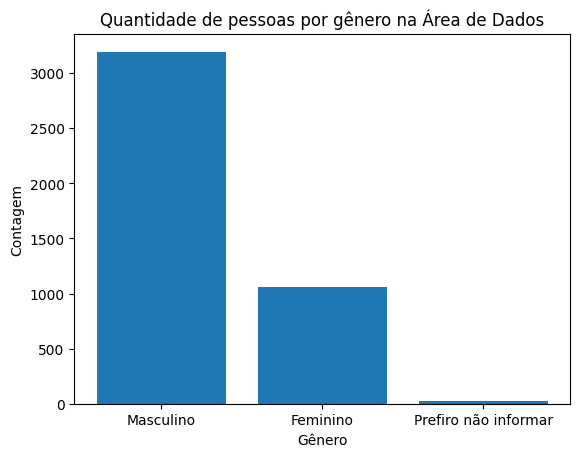

In [ ]:
# Criando o gráfico de barras

plt.figure()
plt.bar(height = genero_counts.values, x = genero_counts.index)  # Configurando a barra
plt.title('Quantidade de pessoas por gênero na Área de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show() # mostrando o gráfico

`plt.bar(height = genero_counts.values, x = genero_counts.index), que recebe a contagem dos valores como parâmetro(value counts)`

Essa função está recebendo como parâmetros
- Height (altura): os valores (.values) da coluna gênero
- o rótulo (x): as categorias que existem, como feminino e masculino

- .index pega as colunas, .values pega os valores

- `plt.title('')` -> título
- `plt.xlabel('')` -> eixo x
- `plt.ylabel('')` -> eixo y





### Biblioteca seaborn
> Seaborn é uma biblioteca de visualização de dados Python baseada em matplotlib. Fornece uma interface de alto nível para desenho gráficos estatísticos atraentes e informativos.

`sns.countplot()` faz a contagem automaticamente a partir dos dados brutos,
sem precisar chamar `value_counts()` antes.

Parâmetros:
- `data`: o DataFrame completo.
- `x`: coluna cujas categorias serão contadas.
- `palette`: paleta de cores (ex: `'pastel'`, `'deep'`, `'muted'`).


In [ ]:
# Importando seaborn
import seaborn as sns

/tmp/ipykernel_1288/567335759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dados_vis, x = 'GENERO', palette = 'pastel')


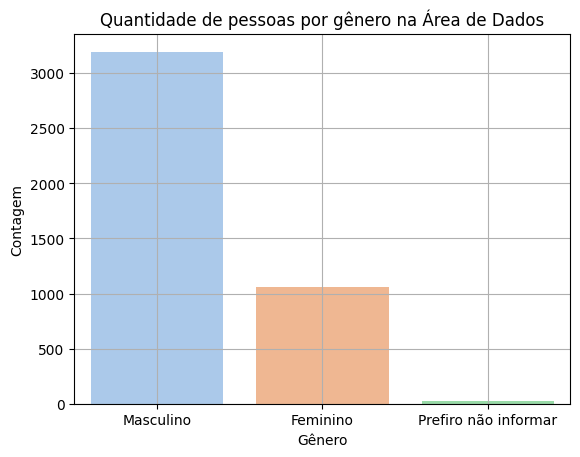

In [ ]:
plt.figure()
# Count plot: mostra a contagem de observações de cada categoria
sns.countplot(data = dados_vis, x = 'GENERO', palette = 'pastel')
# Parâmetros: dados da tabela, x (qual coluna será usada para fazer a contagem) e palette (a cor da paleta)
plt.title('Quantidade de pessoas por gênero na Área de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
# Opcional: linhas de grade
plt.grid(True)
plt.show()


> `sns.countplot(data = , x = , palette = ,)` -> mostra a contagem de observações de cada categoria

>  Parâmetros:
-  data (dados da tabela)
-  x (qual coluna será usada para fazer a contagem)
- palette (a cor da paleta)

> Opcional: linhas de grade
`plt.grid(True)`


In [ ]:
# Será que o salário varia por idade?
salario_por_idade = dados_vis.groupby('IDADE')['SALARIO'].mean()
salario_por_idade

,SALARIO
IDADE,
18.000000,4230.307692
19.000000,4519.590909
20.000000,5004.272727
20.205479,3536.000000
21.000000,4578.737179
22.000000,4394.689815
23.000000,5602.406897
24.000000,6151.622449
25.000000,7616.392336


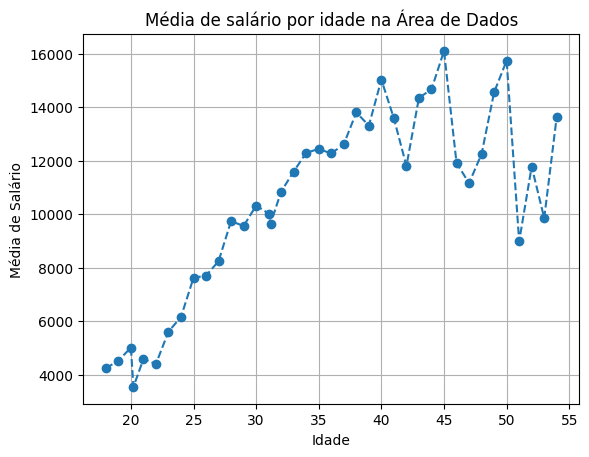

In [ ]:
# Iniciando o gráfico
plt.figure() # Cria uma janela inicial
plt.plot(salario_por_idade.index, salario_por_idade.values, marker = 'o', linestyle = '--')
plt.title('Média de salário por idade na Área de Dados')
plt.xlabel('Idade')
plt.ylabel('Média de Salário')
plt.grid(True)
plt.show()

> `plt.plot()` recebe os parâmetros:
- 1 parâmetro: rótulos do eixo x (index), que são todas as categorias de idade
- 2 parâmetro: valores que preencher eixo y (média de salário por idade)
- marker: define os estilos de marcadores nos pontos de dados
- linestyle:  estilo da linha

### Biblioteca Plotly
> É uma biblioteca gráfica interativa, que oferece gráficos baseados em Python, alimentados por plotly. js. A biblioteca é enviada com mais de 30 tipos de gráficos, incluindo gráficos científicos, gráficos 3D, gráficos estatísticos, mapas SVG, gráficos financeiros e muito mais

> Escolha popular para projetos com visualizações mais avançadas

In [ ]:
# Importanto plotly
import plotly.express as px

In [ ]:
# variável recebe o gráfico
fig = px.line(salario_por_idade.reset_index(), x= 'IDADE', y = 'SALARIO', title = 'Média de salário por idade', markers = True )
# Mostrando a figura
fig.show()

> `px.line()` -> gráfico de linha. Recebe os parâmetros:
- reset_index também funciona como os rótulos do eixo x
- x = qual o nome do eixo x
- y = qual o nome do eixo y
- title = título do gráfico
- markers -> indicar se há marcadores (true/false)

> Criando o scatter plot no matplot lib
`plt.scatter()` recebe os parâmetros iguais ao que vimos, mas tem um a mais:
- alpha: transparência dos pontos no gráfico de dispersão. Quanto mais próximo de zero, mais transparente. Quanto mais próximo de 1, mais opaco.

Parâmetro extra do `plt.scatter()`:
- `alpha`: transparência dos pontos (0 = invisível, 1 = opaco). Útil quando há
  muitos pontos sobrepostos — a transparência revela a densidade.
- `figsize=(largura, altura)` em `plt.figure()` controla o tamanho em polegadas.


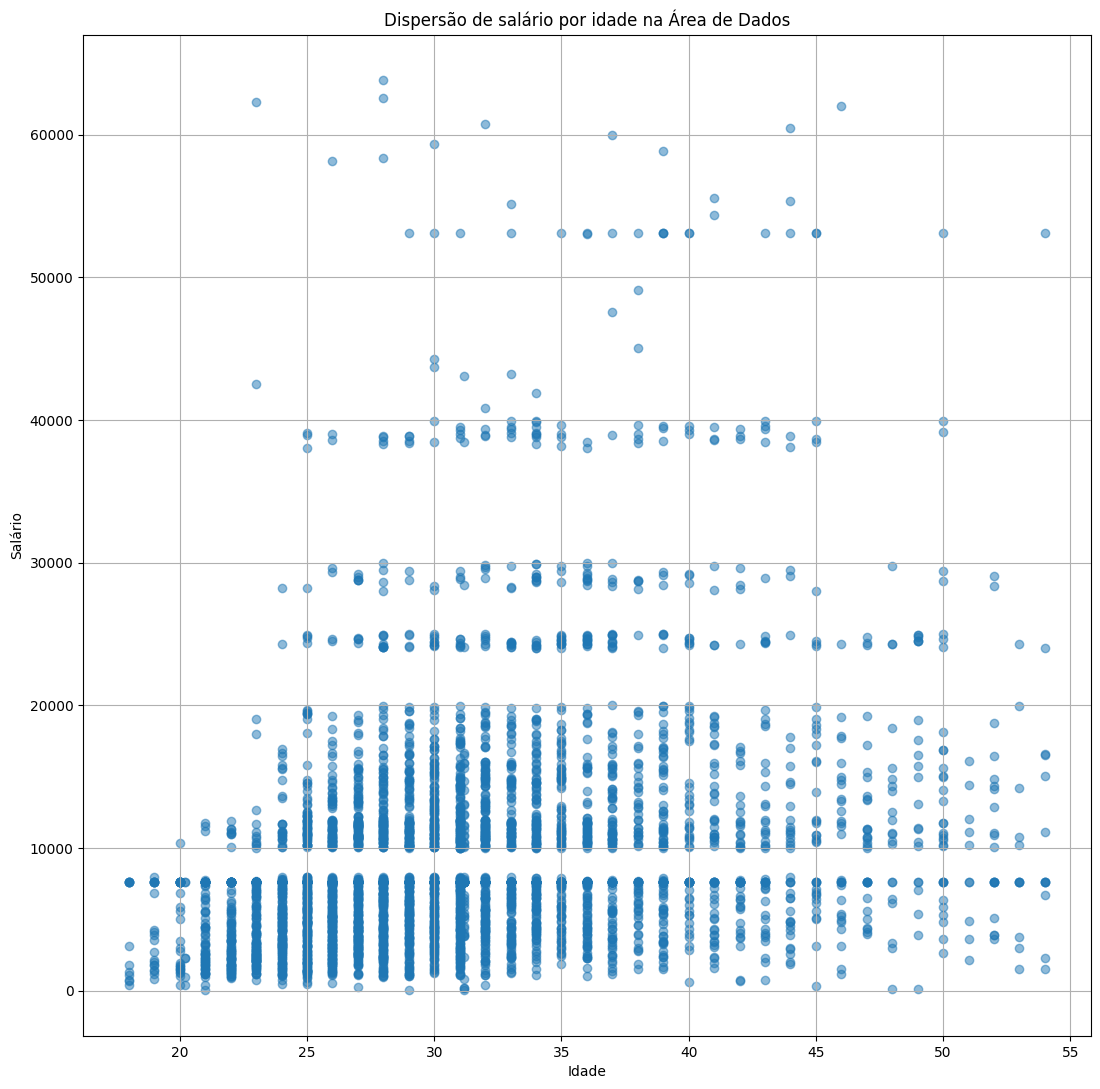

In [ ]:
# Gráfico Scatter Plot usando matplotlib
plt.figure(figsize = (13,13)) # Se quisermos aumentar o tamanho, adicionamos o parametro figsize = (x,y)
plt.scatter(dados_vis['IDADE'], dados['SALARIO'], alpha = 0.5)
plt.title('Dispersão de salário por idade na Área de Dados')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.grid()
plt.show()

> Fazendo o scatter plot no **Plotly**
- utilizamos `px.scatter()` com os mesmos parâmetros que vimos antes no plotly
- Quanto mais dispersos, maior a variabilidade dos dados. Quanto menos, mais homogêneos


In [ ]:
fig = px.scatter(dados, x = 'IDADE', y = 'SALARIO', title = 'Dispersão de salário por idade')
fig.show()